## Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv',index_col=0)
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0


In [3]:
df.shape

(5110, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5110 entries, 9046 to 44679
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.1+ KB


In [5]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df.sample(3)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
7394,Female,57.0,1,0,No,Private,Rural,116.93,28.3,never smoked,0
12175,Female,54.0,0,0,Yes,Private,Urban,104.51,27.3,smokes,1
13622,Male,6.0,0,0,No,children,Rural,92.98,18.9,Unknown,0


## Exploratory Data Analysis (EDA)

<Axes: >

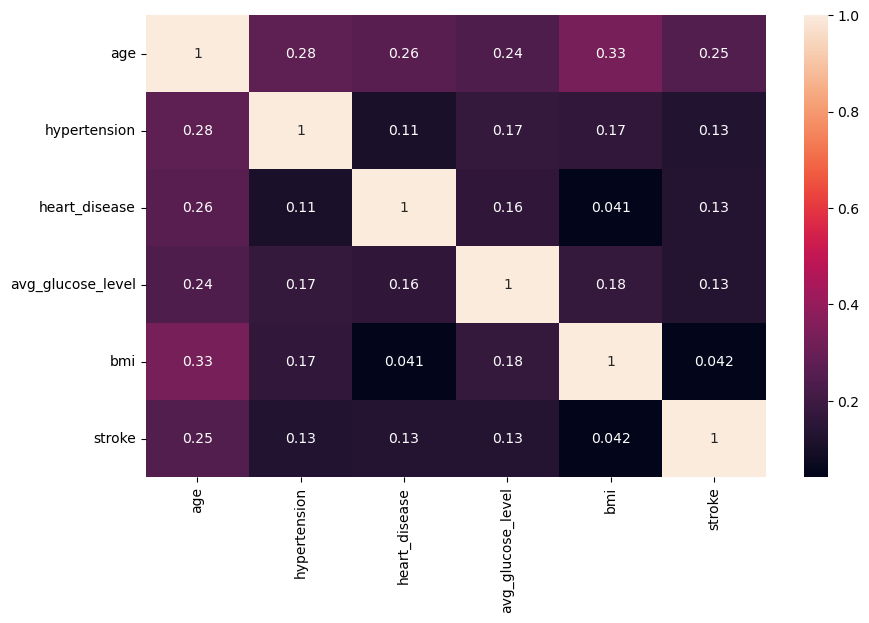

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: ylabel='stroke'>

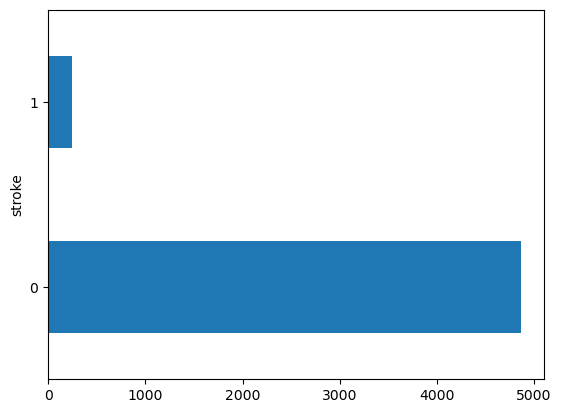

In [8]:
df["stroke"].value_counts().plot(kind='barh')

<Axes: xlabel='age', ylabel='avg_glucose_level'>

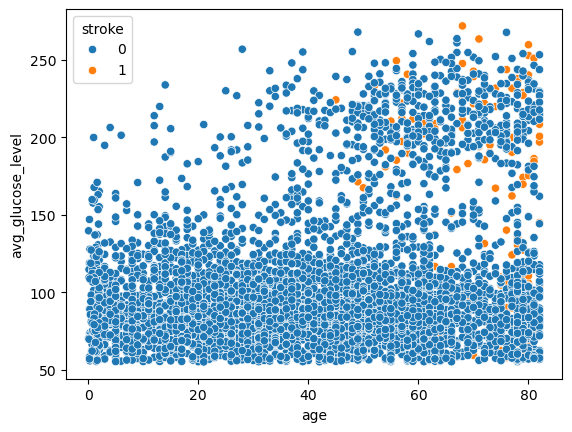

In [9]:
sns.scatterplot(x=df["age"],y=df["avg_glucose_level"],hue=df["stroke"])

## Data Preprocessing

In [10]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

### Outlier Detection

<Axes: >

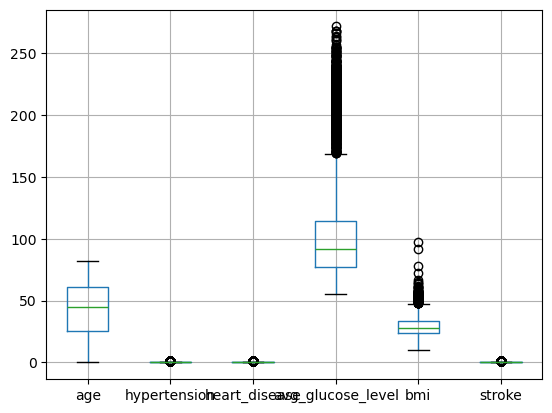

In [12]:
df.boxplot()

In [13]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [14]:
for i in df.select_dtypes(include=object).columns :
    print(i,df[i].unique())

gender ['Male' 'Female' 'Other']
ever_married ['Yes' 'No']
work_type ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type ['Urban' 'Rural']
smoking_status ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [15]:
df = pd.get_dummies(df, columns=df.select_dtypes(include=object).columns, drop_first=True)

## Feature Selection

In [16]:
X = df.drop(columns='stroke')
y = df["stroke"]

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Class imbalance 

In [18]:
print(df['stroke'].value_counts(normalize=True) * 100)

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train,y_train)

print(y_train_resampled.value_counts())

stroke
0    3889
1    3889
Name: count, dtype: int64


# Model Building 

In [20]:
model = AdaBoostClassifier(random_state=42)

model.fit(X_train_resampled,y_train_resampled)

AdaBoostClassifier(random_state=42)

In [21]:
ypred = model.predict(X_test)
ypred

array([0, 0, 0, ..., 0, 0, 0], shape=(1022,))

## Model Evaluation

In [22]:
print("\nAccuracy:", accuracy_score(y_test, ypred))
print("\nClassification Report:")
print(classification_report(y_test, ypred))


Accuracy: 0.8160469667318982

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       972
           1       0.12      0.42      0.18        50

    accuracy                           0.82      1022
   macro avg       0.54      0.63      0.54      1022
weighted avg       0.92      0.82      0.86      1022



## Hyperparameter Tuning

In [23]:
param_grid = {
    'n_estimators':[50,100,200,300,500],
    'learning_rate':[0.01,0.05,0.1,0.5,1]
}

In [24]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [25]:
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'n_estimators': 300, 'learning_rate': 1}
Best CV Score: 0.01905842314237096


In [26]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

In [27]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.952054794520548

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



## Feature Importance

In [28]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

                        Feature  Importance
0                           age    0.673118
4                           bmi    0.225186
3             avg_glucose_level    0.078357
1                  hypertension    0.009023
14  smoking_status_never smoked    0.008589
7              ever_married_Yes    0.005728
2                 heart_disease    0.000000
5                   gender_Male    0.000000
6                  gender_Other    0.000000
8        work_type_Never_worked    0.000000


## Save Model

In [29]:
import joblib

joblib.dump(best_model, "adaboost_model.pkl")

['adaboost_model.pkl']